In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import RandomForestClassifier

In [2]:
# Utilizando dados do scikit-learn
from sklearn.datasets  import load_iris
iris_data=load_iris(as_frame=True)
dados=iris_data.frame
print("Primeiras linhas dos dados Iris: ")
print(dados.head())

Primeiras linhas dos dados Iris: 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [12]:
# Particionar o conjunto de dados (Treinamento e validaçção)  usando train_test_split
x=dados[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']]
y=dados['target']
labels=iris_data.target_names
labels

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
#Dividir os dados em treinamento e teste (equivalente à validação aqui)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.5,stratify=y,random_state=1)

In [5]:
# Ajuste de uma árvore de decisão
arvore1=DecisionTreeClassifier(random_state=1)
arvore1.fit(x_train,y_train)

DecisionTreeClassifier(random_state=1)

In [6]:
# Resumo (em python, podemos inspecionar os atributos da árvore)
print("\nResumo da árvore de decisão: ")
print(f'Número de nós: {arvore1.tree_.node_count}')
print(f'Profundidade da árvore: {arvore1.tree_.max_depth}')
print(f'Limiares de decisão nos nós: {arvore1.tree_.threshold}')


Resumo da árvore de decisão: 
Número de nós: 17
Profundidade da árvore: 6
Limiares de decisão nos nós: [ 0.75       -2.          4.75       -2.          1.75        2.64999998
 -2.          5.04999995 -2.          2.75       -2.         -2.
  4.85000014  5.95000005 -2.         -2.         -2.        ]


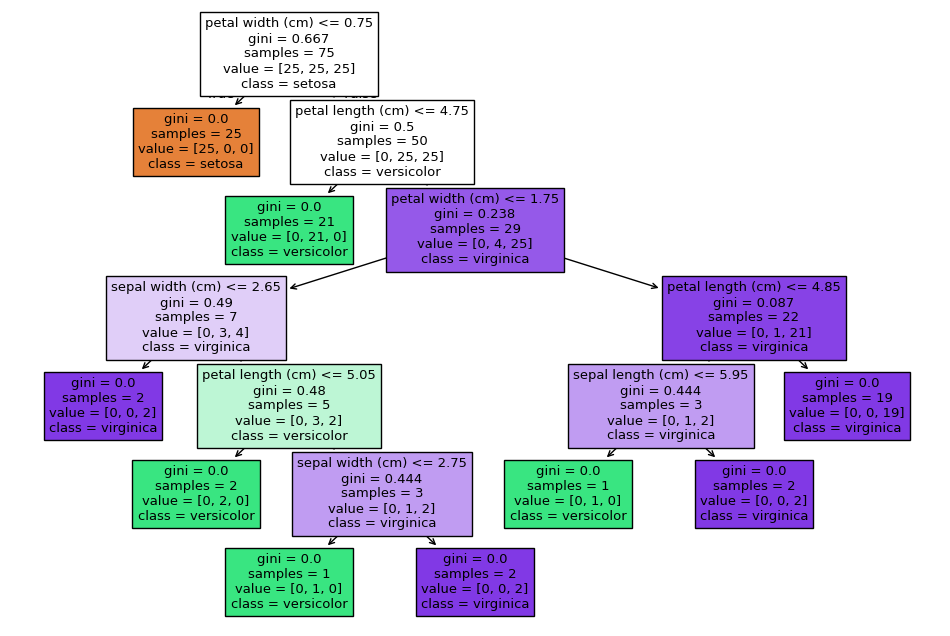

In [7]:
#Apresentação da árvore ajustada
plt.figure(figsize=(12,8))
plot_tree(arvore1,feature_names=x.columns,class_names=labels,filled=True)
plt.show()

In [8]:
## Poda
#Poda da árvore (em python a poda é feita com ccp_alpha)
#À medida que o α aumenta, a penalidade por ter muitos nós aumenta, e a árvore fica menor.
#Árvores menores (maior alfa) são mais simples, mas geralmente têm uma impureza maior nos dados de treino.


# Pegamos os candidatos a alpha

path=arvore1.cost_complexity_pruning_path(x_train,y_train)
cpp_alphas=path.ccp_alphas[:-1] # O último valor em path.ccp_alphas geralmente é o alpha que poda a árvore inteira, restando apenas a raiz (um único nó).


In [9]:
# loop para testar cada alpha

clfs=[]
for alpha in cpp_alphas:
  clf=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
  clf.fit(x_train,y_train)
  clfs.append(clf)



# Criamos a lista de acurácia para cada modelo no set de teste
test_scores = [clf.score(x_test, y_test) for clf in clfs]

# Agora sim, usamos o argmax na lista de scores
indice_melhor_alpha = np.argmax(test_scores)
best_cpp_alpha = cpp_alphas[indice_melhor_alpha]

print(f'Melhor alpha encontrado: {best_cpp_alpha:.6f}')
print(f'Maior acurácia no teste: {test_scores[indice_melhor_alpha]:.2%}')




Melhor alpha encontrado: 0.000000
Maior acurácia no teste: 97.33%


In [10]:
mod_poda=DecisionTreeClassifier(random_state=1,ccp_alpha=best_cpp_alpha)
mod_poda.fit(x_train,y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0), random_state=1)

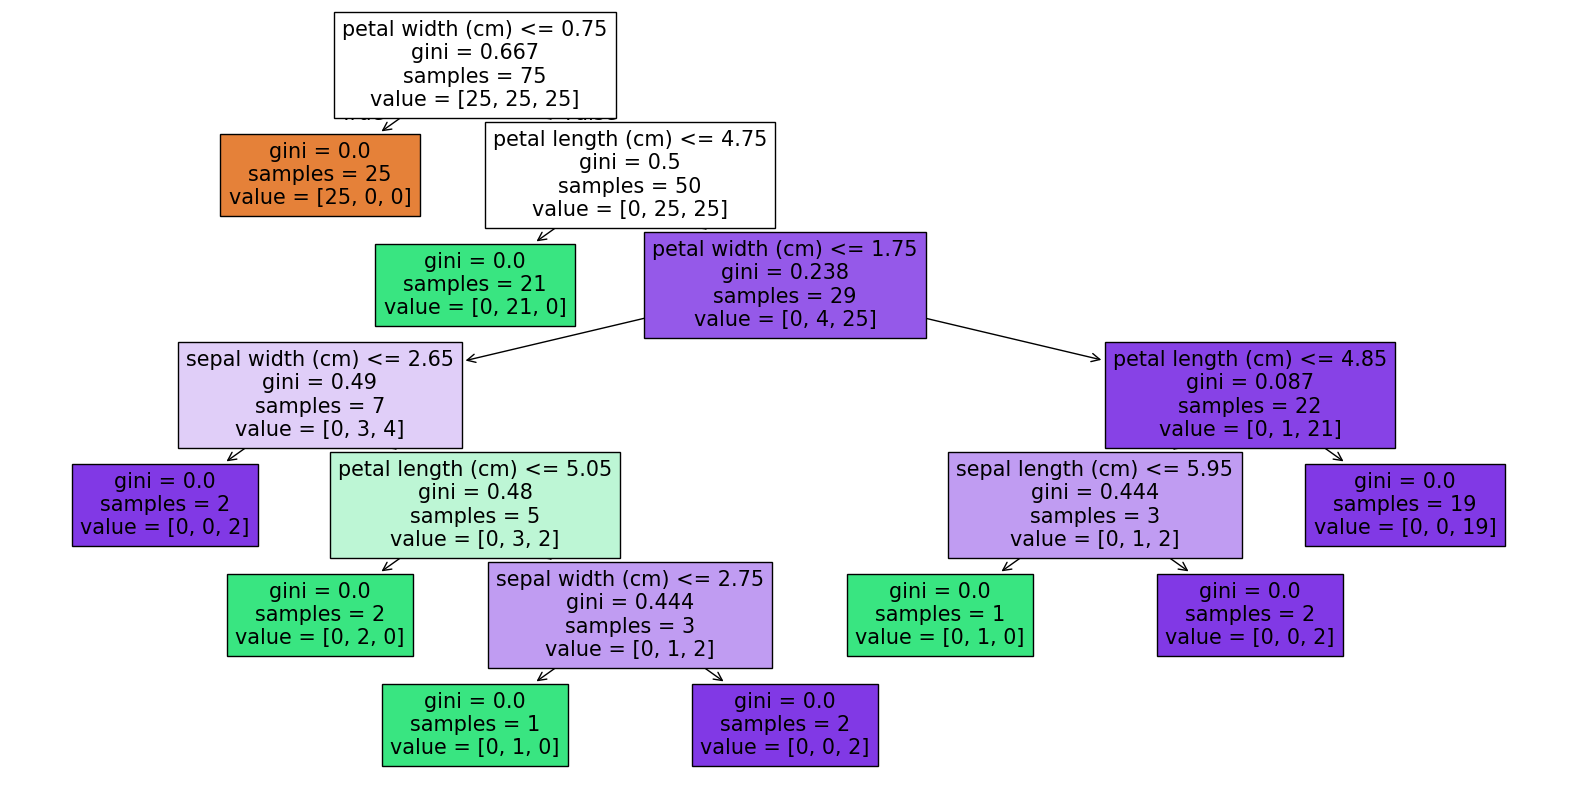

In [11]:
# Apresentação da árvore podada

plt.figure(figsize=(20,10))
plot_tree(mod_poda,filled=True,feature_names=x_train.columns)
plt.show()

In [13]:
# Pedição (considerando o modelo sem "poda" exp[cita])

pred_arv=mod_poda.predict(x_test)
print('\nPrimeiras 10 preições da árvore de decisão ')
print(labels[pred_arv[:10]])


Primeiras 10 preições da árvore de decisão 
['virginica' 'virginica' 'setosa' 'virginica' 'setosa' 'versicolor'
 'versicolor' 'versicolor' 'virginica' 'versicolor']


In [15]:
# Meddas de perfomance
print('\nMatriz de confusão')
cm_arv=confusion_matrix(y_test,pred_arv)
print(cm_arv)

print("\nRelatório de classificação")
print(classification_report(y_test,pred_arv,target_names=labels))





Matriz de confusão
[[25  0  0]
 [ 0 24  1]
 [ 0  1 24]]

Relatório de classificação
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        25
  versicolor       0.96      0.96      0.96        25
   virginica       0.96      0.96      0.96        25

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75



In [18]:
# Acurácia=valores preditos corretamente
print(f'\nAcurácia (árvore de decisão):{accuracy_score(y_test,pred_arv):.4f}')


Acurácia (árvore de decisão):0.9733


In [22]:
#Bagging

bagging=RandomForestClassifier(n_estimators=100,max_features=len(x.columns),random_state=123)
bagging.fit(x_train,y_train)
print("\nModelo bagging ajustado: ")
print(bagging)

# Avaliação do modelo (Predição bagging)

pred_bagg=bagging.predict(x_test)
print('\nMatriz de confusão (bagging): ')
cm_bagg=confusion_matrix(y_test,pred_bagg)
print(cm_bagg)

print("\nRelatório de classificação  (bagging): ")
print(classification_report(y_test,pred_bagg,target_names=labels))

print(f'\nAcurácia (bagging):{accuracy_score(y_test,pred_bagg):.4f}')


Modelo bagging ajustado: 
RandomForestClassifier(max_features=4, random_state=123)

Matriz de confusão (bagging): 
[[25  0  0]
 [ 0 25  0]
 [ 0  1 24]]

Relatório de classificação  (bagging): 
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        25
  versicolor       0.96      1.00      0.98        25
   virginica       1.00      0.96      0.98        25

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75


Acurácia (bagging):0.9867


In [27]:
# Random forest

rf=RandomForestClassifier(n_estimators=100,max_features=2,random_state=1)
rf.fit(x_train,y_train)
print("\nModelo random forest ajustado: ")
print(rf)

# Avaliação do modelo (Predição Random Forest)
pred_rf=rf.predict(x_test)
print('\nMatriz de confusão (random forest): ')
cm_rf=confusion_matrix(y_test,pred_rf)
print(cm_rf)

print("\nRelatório de classificação  (random forest): ")
print(classification_report(y_test,pred_rf,target_names=labels))

print(f'\nAcurácia (random forest):{accuracy_score(y_test,pred_rf):.4f}')



Modelo random forest ajustado: 
RandomForestClassifier(max_features=2, random_state=1)

Matriz de confusão (random forest): 
[[25  0  0]
 [ 0 24  1]
 [ 0  1 24]]

Relatório de classificação  (random forest): 
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        25
  versicolor       0.96      0.96      0.96        25
   virginica       0.96      0.96      0.96        25

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75


Acurácia (random forest):0.9733



Importância das características (Random forest): 
sepal length (cm):0.1670
sepal width (cm):0.0247
petal length (cm):0.4366
petal width (cm):0.3718


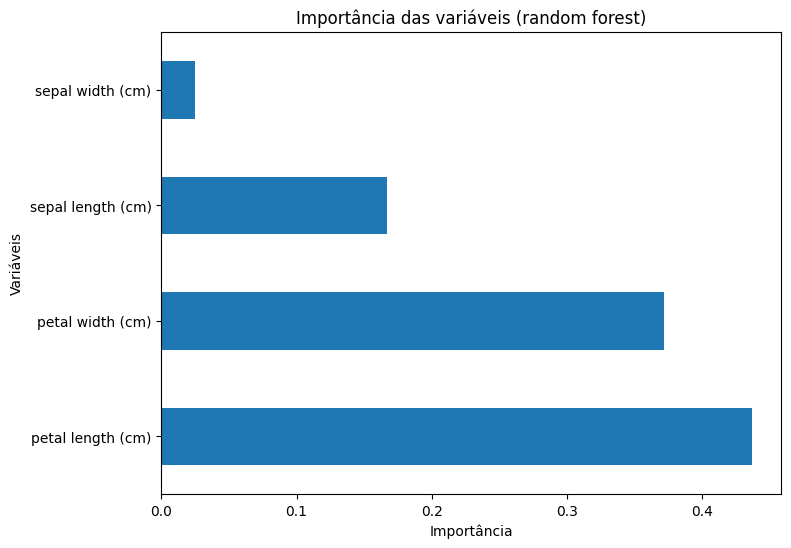

In [31]:
from matplotlib.figure import figaspect
# Importância (baseado na importância das características
i_mod_rf=rf.feature_importances_
print("\nImportância das características (Random forest): ")
for feature,importance in zip(x.columns,i_mod_rf):
  print(f'{feature}:{importance:.4f}')


#varImpPlot (equivalente usando matplotlib)
importances=pd.Series(rf.feature_importances_,index=x.columns)
importances_sorted=importances.sort_values(ascending=False)

plt.figure(  figsize=(8,6))
importances_sorted.plot(kind='barh')
plt.title('Importância das variáveis (random forest)')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.show()

In [33]:
# DataFrame com os resultados

acuracia_data={'Modelo':['AD','Bagging','Random Forest'],'Holdout':[accuracy_score(y_test,pred_arv),accuracy_score(y_test,pred_bagg),accuracy_score(y_test,pred_rf)]}
acuracia_df=pd.DataFrame(acuracia_data)
acuracia_df


,Modelo,Holdout
0,AD,0.973333
1,Bagging,0.986667
2,Random Forest,0.973333
